# 3 Углублённый статистический анализ
**Цель:** Найти корреляцию(связь) между ценой и другими факторами, сравнить типы этажей, выявить влияние высотности дома и определить дисконт за последний этаж

**Данные:** `data/cian_final_cleaned.csv` (результат очистки из `01_data_cleaning.ipynb`)

3.1  Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

3.2 Загрузка очищенных данных

In [2]:
df = pd.read_csv('../data/cian_final_cleaned.csv')

3.3 Вывод первых 5 строк, кол-во строк и колонок датасета

In [3]:
print(df.head(5))
print("\nКоличество строк и колонок")
print(df.shape)

            author        author_type location deal_type accommodation_type  \
0           VESPER          developer   Москва      sale               flat   
1  Аврора Проперти  real_estate_agent   Москва      sale               flat   
2   Мария Науменко            realtor   Москва      sale               flat   
3           VESPER          developer   Москва      sale               flat   
4         NF GROUP  real_estate_agent   Москва      sale               flat   

   floor  floors_count  rooms_count  total_meters        price  ...  \
0      1             6            2         173.3  467910000.0  ...   
1      2             5            3         146.8  400000000.0  ...   
2      9             9            2          44.0   17500000.0  ...   
3      5             9            2         104.2  174388599.0  ...   
4      2             8           -1         235.8  495000000.0  ...   

  house_material_type                   finish_type living_meters  \
0           Кирпичный  Чистов

3.4 Корреляционный анализ Пирсона

Обозначили за X1 - total_meters(независимая переменная), за Y - price(зависимая переменная)

In [4]:
x1 = df['total_meters']
y = df['price']
correlation1 = x1.corr(y)
print(f"\nЗависимость цены от общей площади: {correlation1:.4f}")
print("Сильная положительная связь: чем больше площадь, тем выше цена")


Зависимость цены от общей площади: 0.8002
Сильная положительная связь: чем больше площадь, тем выше цена


Обозначили за X2 - rooms_count(независимая переменная), за Y - price(зависимая переменная)

In [5]:
x2 = df['rooms_count']
y = df['price']
correlation2 = x2.corr(y)
print(f"\nЗависимость цены от количества комнат: {correlation2:.4f}")
print("Слабая отрицательная связь: количество комнат почти не влияют на стоимость")


Зависимость цены от количества комнат: -0.0224
Слабая отрицательная связь: количество комнат почти не влияют на стоимость


Обозначили за X3 - floor(независимая переменная), за Y - price(зависимая переменная)

In [6]:
x3 = df['floor']
y = df['price']
correlation3 = x3.corr(y)
print(f"\nЗависимость цены от этажа: {correlation3:.4f}")
print("Слабая отрицательная связь: чем выше этаж, тем дешевле цена")


Зависимость цены от этажа: -0.0592
Слабая отрицательная связь: чем выше этаж, тем дешевле цена


Обозначили за X4 - floors_count(независимая переменная), за Y - price(зависимая переменная)

In [7]:
x4 = df['floors_count']
y = df['price']
correlation4 = x4.corr(y)
print(f"\nЗависимость цены от этажности дома: {correlation4:.4f}")
print("Умеренная отрицательная связь: чем выше дом, тем дешевле цена")


Зависимость цены от этажности дома: -0.2141
Умеренная отрицательная связь: чем выше дом, тем дешевле цена


3.5 Сравнили типы этажей

Классифицировали этажи: Первый, Средний, Последний

In [8]:
conditions = [
    df['floor'] == 1,
    df['floor'] == df['floors_count']
]
choice = ['Первый', 'Последний']

df['floor_type'] = np.select(conditions, choice, default='Средний')
print("\nТипы этажей:")
print(df[['floors_count', 'floor', 'floor_type']])


Типы этажей:
      floors_count  floor floor_type
0                6      1     Первый
1                5      2    Средний
2                9      9  Последний
3                9      5    Средний
4                8      2    Средний
...            ...    ...        ...
1282            17     17  Последний
1283            15      8    Средний
1284            13     11    Средний
1285             5      5  Последний
1286            16     14    Средний

[1287 rows x 3 columns]


3.6 Посчитали среднюю цену за квадратный метр для каждого этажа, удалив выбросы - квартриры дороже 1.5 млн рублей

In [9]:
df_filtered1 = df[df['price_per_m2'] < 1500000]

count_for_floortytype = df_filtered1.groupby('floor_type')['price_per_m2'].median().round(0)
print("\nСредняя цена за квадратный метр для каждого этажа")
print(count_for_floortytype)


Средняя цена за квадратный метр для каждого этажа
floor_type
Первый       487597.0
Последний    718658.0
Средний      693620.0
Name: price_per_m2, dtype: float64


3.7 Определили какой тип этажа самый дорогой и самый дешёвый

In [10]:
print(f"\nСамый дешёвый этаж - {count_for_floortytype.idxmin()}: {count_for_floortytype.min():.0f}")
print(f"\nСамый дорогой этаж - {count_for_floortytype.idxmax()}: {count_for_floortytype.max():.0f}")
print("\nПервый этаж - самый доступный сегмент \nСредний этаж - основной объем предложений с базовой ценой \nПоследний этаж не имеет дисконта в данной выборке и даже дороже среднего, что может объясняться наличием улучшенных планировок или пентхаусов")


Самый дешёвый этаж - Первый: 487597

Самый дорогой этаж - Последний: 718658

Первый этаж - самый доступный сегмент 
Средний этаж - основной объем предложений с базовой ценой 
Последний этаж не имеет дисконта в данной выборке и даже дороже среднего, что может объясняться наличием улучшенных планировок или пентхаусов


3.8 Определили влияние высотности дома. Разбили дома на категории: Малоэтажные(1-5), Среднеэтажные(6-10), Многоэтажные(11-20), Высотные(21+)

In [11]:
floor_category = [
    (df['floors_count'] >=1) & (df['floors_count'] <= 5),
    (df['floors_count'] >=6) & (df['floors_count'] <= 10),
    (df['floors_count'] >=11) & (df['floors_count'] <= 20),
    df['floors_count'] >= 21
]
category_name = ['Малоэтажный', 'Среднеэтажный', 'Многоэтажный', 'Высотный',]

df['floor_height'] = np.select(floor_category, category_name, default='Неизвестно')
print("\nЭтажности домов:")
print(df[['floors_count','floor_height']].head(15))


Этажности домов:
    floors_count   floor_height
0              6  Среднеэтажный
1              5    Малоэтажный
2              9  Среднеэтажный
3              9  Среднеэтажный
4              8  Среднеэтажный
5              8  Среднеэтажный
6             21       Высотный
7             20   Многоэтажный
8             34       Высотный
9              8  Среднеэтажный
10             9  Среднеэтажный
11            27       Высотный
12             7  Среднеэтажный
13            16   Многоэтажный
14            13   Многоэтажный


3.9 Посчитали среднюю цену за квадратный метр в каждой категории

In [12]:
count_of_floorheight = df.groupby('floor_height')['price_per_m2'].median().round(0)
print("\nСредняя цена за квадратный метр для каждой группы высотности дома")
print(count_of_floorheight)


Средняя цена за квадратный метр для каждой группы высотности дома
floor_height
Высотный          643407.0
Малоэтажный       902256.0
Многоэтажный      763924.0
Среднеэтажный    1043922.0
Name: price_per_m2, dtype: float64


3.10 Определим дисконт за последний этаж (цена последних / цена средних - 1) * 100, удалив выбросы - квартриры дороже 1.5 млн рублей

In [13]:
df_filtered2 = df[df['price_per_m2'] < 1500000]

prices = df_filtered2.groupby('floor_type')['price_per_m2'].median()
last = prices['Последний']
middle = prices['Средний']
discont = (last / middle-1)*100
print(f"\nЦена последних этажей отличается от средних на: {discont:.2f}%")


Цена последних этажей отличается от средних на: 3.61%


3.11 Столбчатая диаграмма средней цены за квадратный метр для каждого этажа

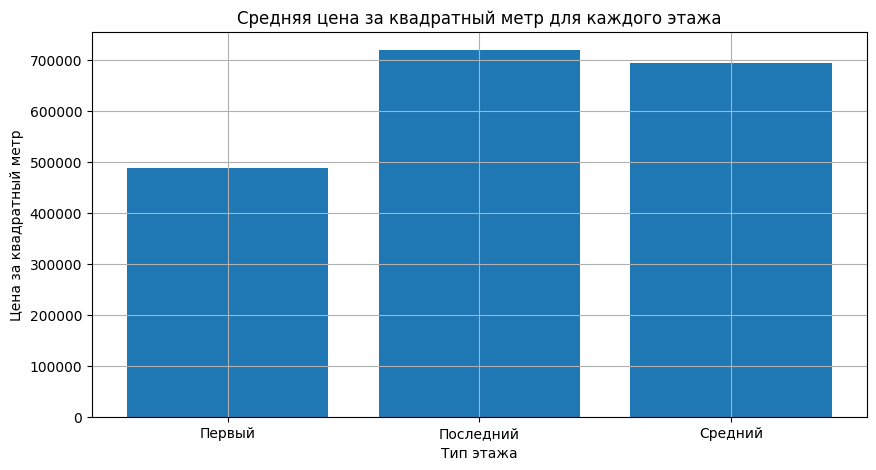

In [14]:
graph1 = df_filtered1.groupby('floor_type')['price_per_m2'].median().round(0)

plt.figure(figsize=(10, 5))
plt.bar(graph1.index , graph1.values)
plt.title("Средняя цена за квадратный метр для каждого этажа")
plt.xlabel("Тип этажа")
plt.ylabel("Цена за квадратный метр")
plt.grid(True)
plt.show()

3.12 Столбчатая диаграмма средний цены за квадратный метр в каждой категории этажности

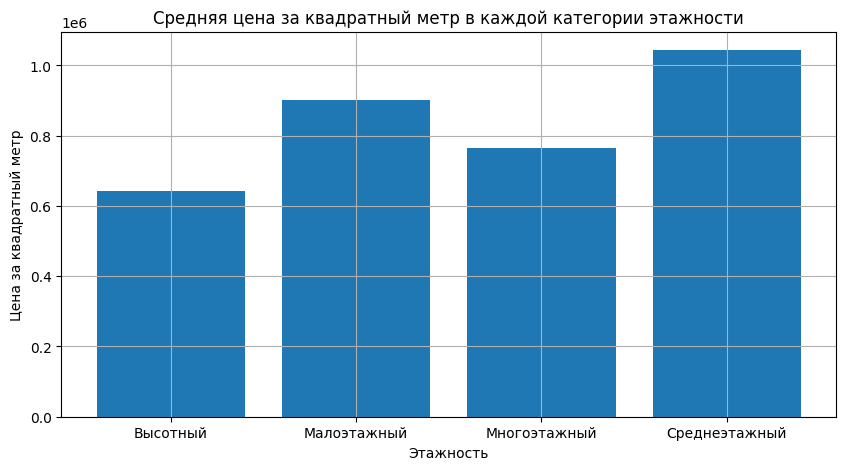

In [15]:
graph2 = df.groupby('floor_height')['price_per_m2'].median().round(0)

plt.figure(figsize=(10, 5))
plt.bar(graph2.index, graph2.values)
plt.title("Средняя цена за квадратный метр в каждой категории этажности")
plt.xlabel("Этажность")
plt.ylabel("Цена за квадратный метр")
plt.grid(True)
plt.show()

3.13 Матрица корреляции для всех числовых признаков

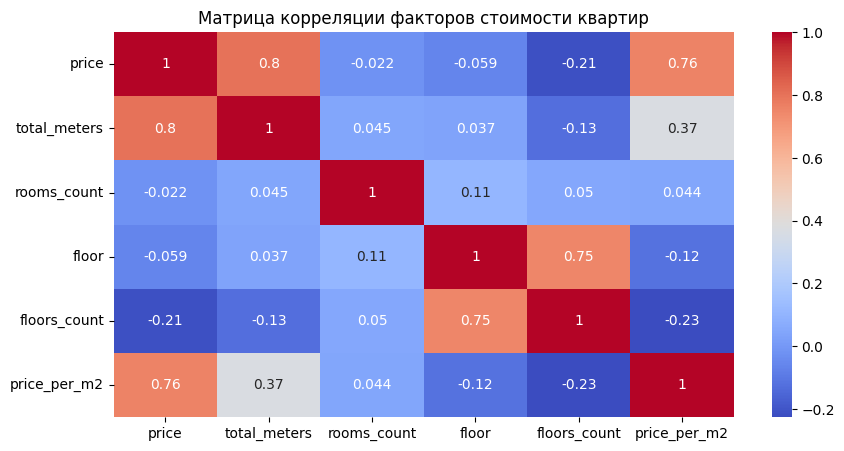

In [16]:
numeric_df = df[['price', 'total_meters', 'rooms_count', 'floor', 'floors_count', 'price_per_m2']]
plt.figure(figsize=(10,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляции факторов стоимости квартир')
plt.show()